#### Teoría de los Circuitos 2
# Trabajo de Laboratorio #1
#### Leandro Robledo

## Filtro (OPAMP)
# Tipo:Notch 50 Hz	10 Hz, BW @ 3dB    

### [Introduccion](#intro)

### Análisis y Simulacion [( Pre-Lab )](#prelab)

[Obtener el orden del filtro y hallar la función transferencia total.](#Orden)

[Obtener la transferencia de la red circuital a implementar.](#Transferencia)

[Simulación numérica/simbólica](#simpy) de la función transferencia en Python. 

[Simulación circuital.](#simuCirc) Incluya el modelo real del OPAMP.  

### Implementacion y armado [( Pre-Lab )](#armado)
[Disenar el Layout del PCB.](#layout)


### Medicion [( In-Lab )](#medicion)


## Introduccion <a id="intro"></a>
En el presente trabajo de laboratorio se realizo un filtro pasabanda de tipo $\textbf{Notch}$, de una frecuencia de stop de $50Hz$ con $3db$ de ripple. Este filtro resulta sumamente util para practicamente cualquier dispositivo electronico ya que, como es sabido, la frecuencia seleccionada es en la cual funciona la red de alimentacion domestica por lo que es muy comun que en el analisis y levantamiento de señales aparezca ruido en esta frecuencia especifica.

Se propuso como circuito resolutivo la topología Ackerberg-Mosberg, complementada con una etapa sumadora a la salida. Esta red circuital nos permite sintetizar la función notch con bastante facilidad al trabajar con una combinación de las salidas pasa-todo (la entrada) y pasa-banda, sumadas adecuadamente para obtener un cero en la frecuencia deseada. Posee como ventaja la utilizacion de una considerable cantidad de componentes que peromiten variar el diseño y sensibilidad para adecuarlo a nuestros requerimientos, a su vez se decidio la utilizacion repetitiva de ciertos componentes y la implementacion de componentes variables estrategicos a fin de poder reducir al maximo las imperfecciones por dispersion de propia de los materiales.

El desarrollo del trabajo se estructuró en distintas etapas, correspondientes a las fases de diseño, simulación y validación experimental. En primer lugar, se realizó el cálculo analítico de la función transferencia y el dimensionamiento de los componentes del circuito, verificando su comportamiento mediante simulación matemática en Python y circuital en LTspice, incorporando el modelo real del amplificador operacional utilizado, con el fin de contrastar el comportamiento ideal con el que presentaría el circuito físico. A partir de este diseño validado, se procedió al armado del PCB correspondiente.

En la etapa de laboratorio, se realizó un barrido en frecuencia utilizando señales senoidales generadas con un generador de funciones, midiendo la respuesta del filtro (entrada y salida) mediante un osciloscopio digital, con el objetivo de graficar experimentalmente la curva de transferencia y compararla con la respuesta teórica y simulada. Finalmente, se empleó un analizador de espectros para verificar de manera complementaria la respuesta en frecuencia del filtro, permitiendo constatar los resultados obtenidos por ambos métodos de medición de manera mas rigurosa y confiable.

## Análisis y Simulacion ( Pre-Lab )<a id="prelab"></a>
#### Orden de la transferencia <a id="Orden"></a>
Como no fue pedido ningun $\alpha_min$ de atenuacion no se delimito un orden especifico al cual deberiamos llegar, por lo que para implementar un circuito simple pero robusto en el que la gran cantidad de componentes pasivos o activos no sea una problematica en el encadenamiento de etapas se optó por una trasnferencia de segundo orden la cual demostro una excelente respuesta la cual satisfazo nuestros requerimientos.
![Orden del filtro](OrdenFil.jpeg)

#### [Transferencia de la red circuital.](#Transferencia)<a id="Transferencia"></a>
La trasnferencia se calculo sobre el circuito mostrado a continuacion:
![Circuito](Circuito.jpeg)
![Transferencia completa](Transferencia.jpeg)

[Simulación numérica/simbólica](#simpy)<a id="simpy"></a>
A continuacion se muestra lo obtenido por la simulacion de la trasnferencia por las librerias de la catedra:


In [1]:
# Librerías externas NumPy, SciPy y Matplotlib
from scipy.signal import TransferFunction
import matplotlib.pyplot as plt
import numpy as np
from pytc2.sistemas_lineales import pretty_print_lti
from pytc2.sistemas_lineales import analyze_sys, pretty_print_bicuad_omegayq, tf2sos_analog, pretty_print_SOS
from pytc2.general import print_subtitle
from pytc2.sistemas_lineales import pzmap, GroupDelay, bodePlot
from sympy import *

The history saving thread hit an unexpected error (OperationalError('attempt to write a readonly database')).History will not be written to the database.


<IPython.core.display.Math object>

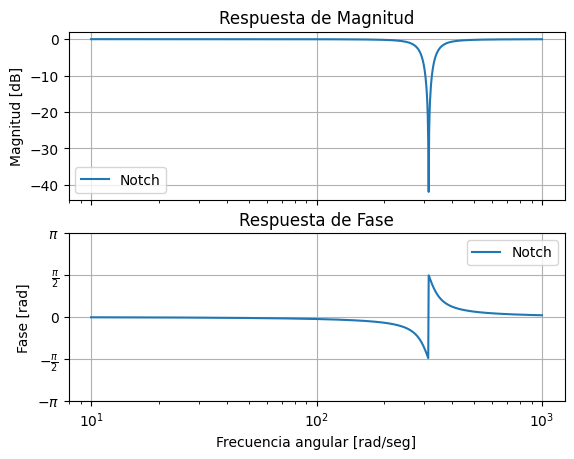

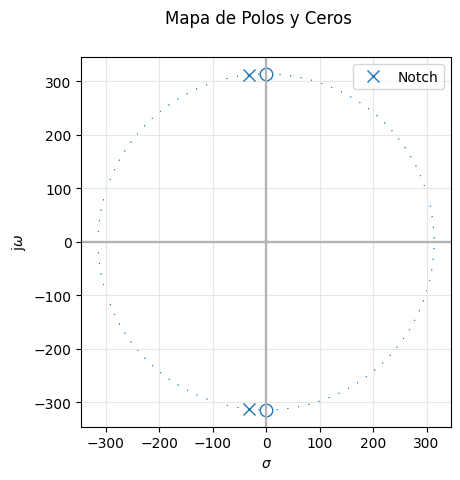

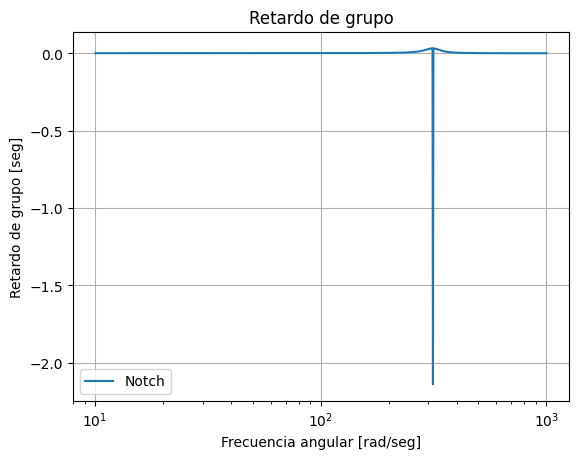

In [4]:
#notch con ackerberg
Q=5
W=100*np.pi

#Transferencia
num = [1,0,W**2]   # 1
den = [1,W/(Q),W**2]


my_tf = TransferFunction(num, den)

plt.close('all')

bodePlot(my_tf, fig_id=1, filter_description = 'Notch')

pzmap(my_tf, fig_id=2, filter_description = 'Notch')

GroupDelay(my_tf, fig_id=3, filter_description = 'Notch')

this_sos = tf2sos_analog(num, den)
pretty_print_SOS(this_sos, mode='omegayq')

#### [Simulación circuital.](#simuCirc)<a id="simuCirc"></a>
Circuito implementado en LTspice con $\textbf{Ampilifacores Operacionales TL081}$
![Simulacion LTspice](Simu_Circ.png)
Respuesta de modulo y fase:
![Modulo y fase del circuito](ModYFase.jpeg)

### Implementacion y armado [( Pre-Lab )](#armado))<a id="armado"></a>
Para la realizacion del filtro y dado la complegidad y necesidad de precision de ciertos aspectos para su correcto funcionamiento se tomaron las siguientes decisiones de diseño:
- Diseño en plaqueta con CNC
- Conectores de tipo BNC para la entrada y salida de las señales a fin de conservar al maximo la aislación de los cables entre los dispositivos de fuente y medición.
- Potenciometros multivueltas para una mayor precision, estrategicos en la ubicacion de la calculada R3, la cual se encargaba de ajustar la frecuencia de corte del filtro.
- Zocalo dip 14 para el amplificador operacional, este fue de especial ayuda ya que durante el armado y uso del filtro hubieron errores por los que tuvimos que reemplazar el operacional empleado.
- Capacitores de bypass en la enrtada de alimentacion para limpiar el ruido de fuente.

![Esquematico del PCB](Esquematico.png)

Se puede ver una orientacion de las entradas y salidas en lados opuestos para facilitar la conexion ademas de evitar errores, tambien cabe aclarar que la eficiencia del espacio no fue el mayor objetivo del diseño, sino el de obtener una placa funcional y que permita un manejo sencillo de las diferentes practicas de medicion durante el laboratorio.  
![Layout del PCB](Layout.png)

Por ultimo adjuntamos imagenes de como resulto la plaqueta final. Tuvimos que sobrepasar una serie de distintas dificultades durante su armado como problemas con el uso de la CNC hasta problemas de diseño acarreados desde el esquematico, sin embargo podriamos decir que todos estos problemas fueron solucionados con exito para el dia de la entrega.  
![Plaqueta vista superior](Plaqueta_TOP.jpeg)  
![Plaqueta vista inferior](Plaqueta_BOT.jpeg)


### Implementacion y armado [( Pre-Lab )](#armado))<a id="armado"></a>

Luego de verificar de que no haya ningun cortocircuito u otro desperfecto que impida el trabajo del filtro, se alimento utilizando una fuente de tension con corriente regulada, a fin de no dañar en lo posible el circuito integrado. 
Se realizo el siguiente barrido en frecuencia para verificar su correcto funcionamiento:

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from io import StringIO

plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['axes.grid'] = True

# --- Funciones de parseo (definir SIEMPRE antes de usarlas) ---

def parse_estandar(valor):
    """Números con punto decimal normal, sin bug."""
    return float(str(valor).strip())

def parse_coma_decimal(valor):
    """Convierte números con coma decimal (formato ARG/ES) a float."""
    s = str(valor).strip()
    if ',' in s:
        s = s.replace('.', '').replace(',', '.')
    return float(s)

def parse_multidot(valor):
    """
    Corrige el bug de formato regional: cuando la parte decimal quedó
    agrupada con puntos de miles, ej: '-1.108.354' -> -1.108354
    """
    s = str(valor).strip()
    negativo = s.startswith('-')
    if negativo:
        s = s[1:]
    if s.count('.') <= 1:
        resultado = float(s)
    else:
        partes = s.split('.')
        entero = partes[0]
        decimales = ''.join(partes[1:])
        resultado = float(f"{entero}.{decimales}")
    return -resultado if negativo else resultado

# --- Datos crudos ---

data_raw = """Frecuencia [Hz]\tVout [mV]\tVout [dB]\tDelta T [mS]\tFase [rad]\tRetardo [mS]
10.00\t1000\t0.00\t1,20\t-0.075398\t0,4000
20.00\t1000\t0.00\t0,80\t-0.100531\t1,4000
30.00\t980\t-0.18\t1,00\t-0.188496\t3,8000
40.00\t980\t-0.18\t1,70\t-0.427257\t9,8000
45.00\t760\t-2.38\t2,60\t-0.735133\t16,7000
47.00\t580\t-4.73\t3,20\t-0.944991\t3,2000
47.65\t500\t-6.02\t3,20\t-0.958060\t3,2000
48.00\t400\t-7.96\t3,20\t-0.965097\t22,8000
49.00\t250\t-12.04\t3,60\t-1.108.354\t43,0000
49.25\t210\t-13.56\t3,80\t-1.175.898\t-127,9333
49.40\t200\t-13.98\t3,40\t-1.055.324\t-95,6000
49.50\t160\t-15.92\t3,20\t-0.995257\t3,2000
49.75\t150\t-16.48\t3,20\t-1.000.283\t-196,8000
50.00\t80\t-21.94\t2,20\t-0.691150\t402,6000
50.05\t100\t-20.00\t2,60\t-0.817631\t-198,0000
50.15\t80\t-21.94\t2,20\t-0.693224\t-1002,8000
50.25\t64\t-23.88\t0,20\t-0.063146\t0,2000
50.40\t60\t-24.44\t0,20\t-0.063335\t-1009,8000
50.50\t80\t-21.94\t-1,80\t0.571142\t-83,0000
50.75\t82\t-21.72\t-2,20\t0.701518\t-103,9000
50.85\t100\t-20.00\t-2,40\t0.766800\t-274,4000
51.00\t160\t-15.92\t-3,20\t1.025.416\t-3,2000
51.50\t200\t-13.98\t-3,20\t1.035.469\t-3,2000
52.00\t300\t-10.46\t-3,20\t1.045.522\t9,8061
53.65\t500\t-6.02\t-2,80\t0.943860\t28,0571
54.00\t560\t-5.04\t-2,60\t0.882159\t14,2000
56.00\t720\t-2.85\t-2,00\t0.703717\t9,6000
58.00\t800\t-1.94\t-1,60\t0.583080\t-1,6000
60.00\t840\t-1.51\t-1,60\t0.603186\t8,8000
65.00\t900\t-0.92\t-0,80\t0.326726\t2,0000
70.00\t980\t-0.18\t-0,60\t0.263894\t0,6800
80.00\t1000\t0.00\t-0,44\t0.221168\t1,0000
90.00\t1000\t0.00\t-0,28\t0.158336\t-0,2800
100.00\t1000\t0.00\t-0,28\t0.175929\t-0,2800"""

# --- Cargar y limpiar ---

df = pd.read_csv(StringIO(data_raw), sep='\t')

df['Frecuencia [Hz]']  = df['Frecuencia [Hz]'].apply(parse_estandar)
df['Vout [mV]']        = df['Vout [mV]'].apply(parse_estandar)
df['Vout [dB]']        = df['Vout [dB]'].apply(parse_estandar)
df['Delta T [mS]']     = df['Delta T [mS]'].apply(parse_coma_decimal)
df['Fase [rad]']       = df['Fase [rad]'].apply(parse_multidot)
df['Retardo [mS]']     = df['Retardo [mS]'].apply(parse_coma_decimal)

df = df.sort_values('Frecuencia [Hz]').reset_index(drop=True)

print(df.dtypes)
df

Frecuencia [Hz]    float64
Vout [mV]          float64
Vout [dB]          float64
Delta T [mS]       float64
Fase [rad]         float64
Retardo [mS]       float64
dtype: object


,Frecuencia [Hz],Vout [mV],Vout [dB],Delta T [mS],Fase [rad],Retardo [mS]
0,10.00,1000.0,0.00,1.20,-0.075398,0.4000
1,20.00,1000.0,0.00,0.80,-0.100531,1.4000
2,30.00,980.0,-0.18,1.00,-0.188496,3.8000
3,40.00,980.0,-0.18,1.70,-0.427257,9.8000
4,45.00,760.0,-2.38,2.60,-0.735133,16.7000
5,47.00,580.0,-4.73,3.20,-0.944991,3.2000
6,47.65,500.0,-6.02,3.20,-0.958060,3.2000
7,48.00,400.0,-7.96,3.20,-0.965097,22.8000
8,49.00,250.0,-12.04,3.60,-1.108354,43.0000
9,49.25,210.0,-13.56,3.80,-1.175898,-127.9333


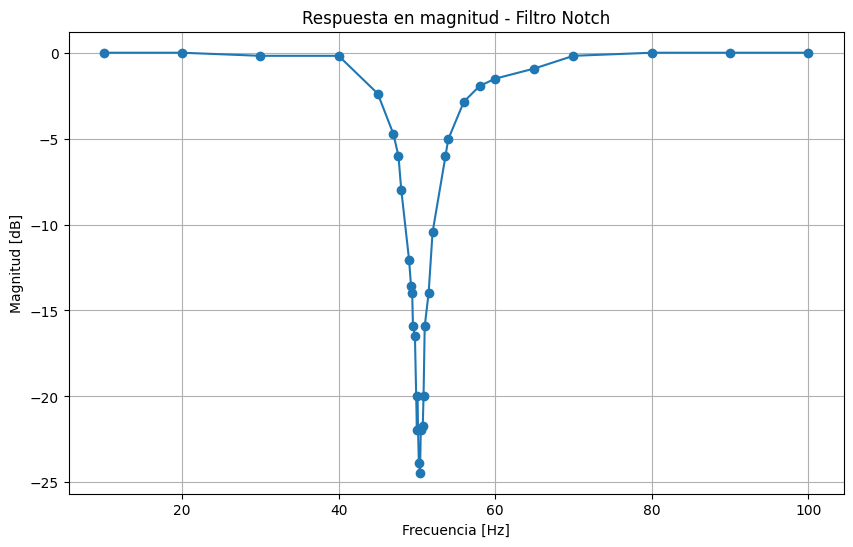

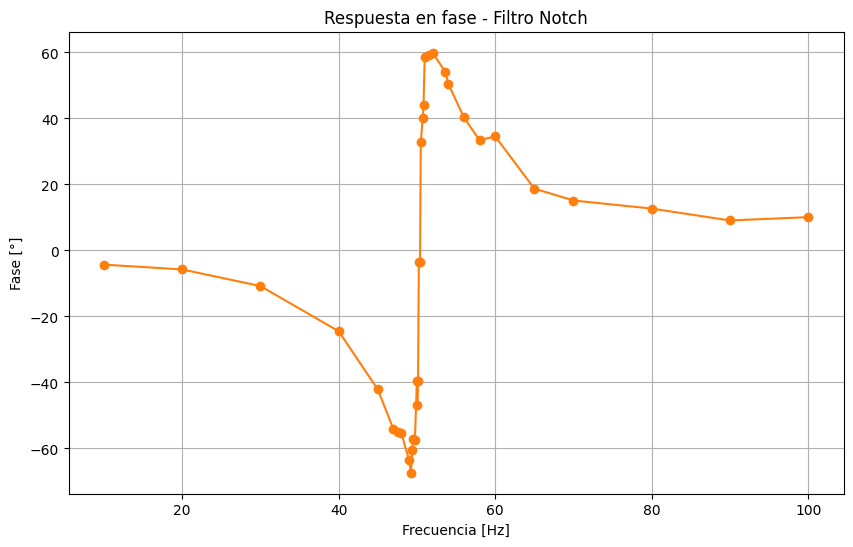

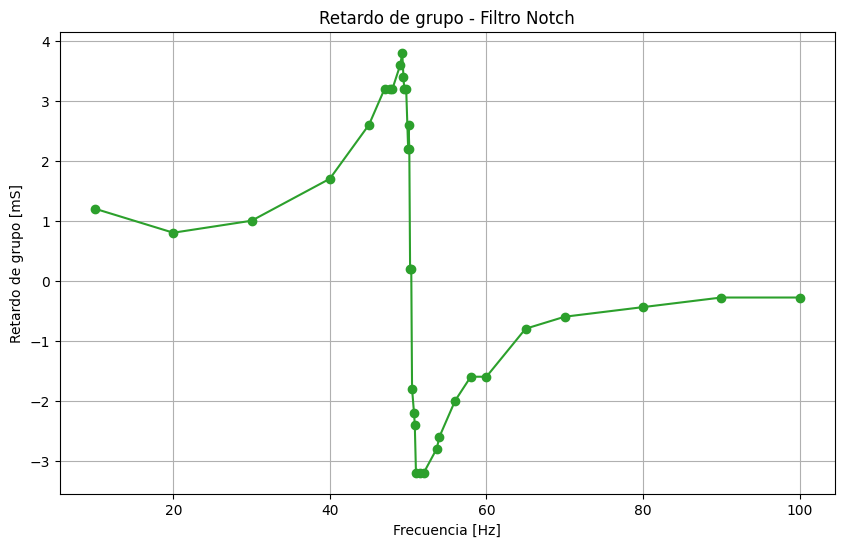

In [4]:
## grafico simple por union de puntos ###
# --- Gráfico 1: Módulo (magnitud) ---
plt.figure()
plt.plot(df['Frecuencia [Hz]'], df['Vout [dB]'], marker='o', linestyle='-')
plt.xlabel('Frecuencia [Hz]')
plt.ylabel('Magnitud [dB]')
plt.title('Respuesta en magnitud - Filtro Notch')
plt.grid(True)
plt.show()

# --- Gráfico 2: Fase ---
plt.figure()
plt.plot(df['Frecuencia [Hz]'], np.degrees(df['Fase [rad]']), marker='o', linestyle='-', color='tab:orange')
plt.xlabel('Frecuencia [Hz]')
plt.ylabel('Fase [°]')
plt.title('Respuesta en fase - Filtro Notch')
plt.grid(True)
plt.show()

# --- Gráfico 3: Retardo de grupo (Delta T) ---
plt.figure()
plt.plot(df['Frecuencia [Hz]'], df['Delta T [mS]'], marker='o', linestyle='-', color='tab:green')
plt.xlabel('Frecuencia [Hz]')
plt.ylabel('Retardo de grupo [mS]')
plt.title('Retardo de grupo - Filtro Notch')
plt.grid(True)
plt.show()

Nivel de banda de paso (referencia): -0.04 dB
Frecuencia central f0: 50.360 Hz
Magnitud mínima: -24.39 dB
Profundidad del notch: 24.35 dB
Umbral -3 dB: -3.04 dB
Frecuencia de corte inferior (-3dB): 45.676 Hz
Frecuencia de corte superior (-3dB): 55.676 Hz
Ancho de banda (BW): 10.000 Hz
Factor Q: 5.04


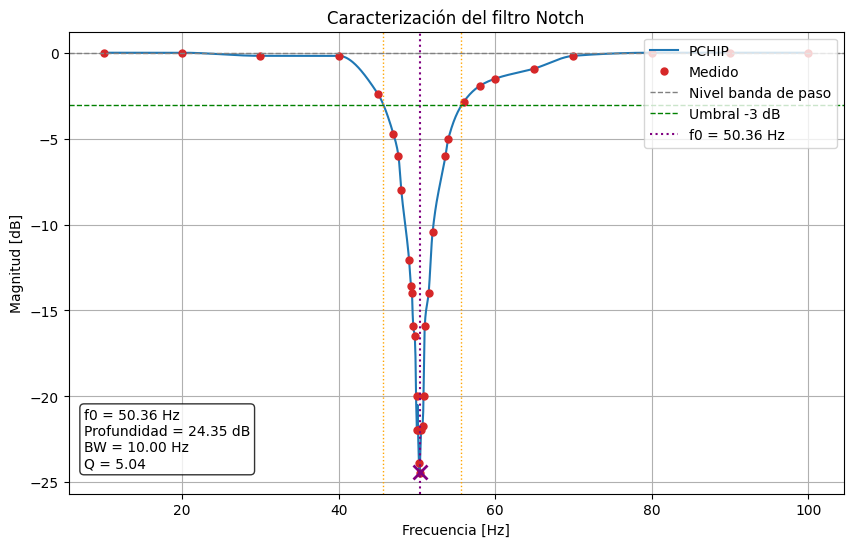

Frecuencia de cruce por cero de fase: 50.360 Hz
Fase en f0: -3.63°
Swing de fase en la zona del notch: 126.83° (de -66.93° a 59.90°)
Pendiente de fase en f0: -0.08 °/Hz


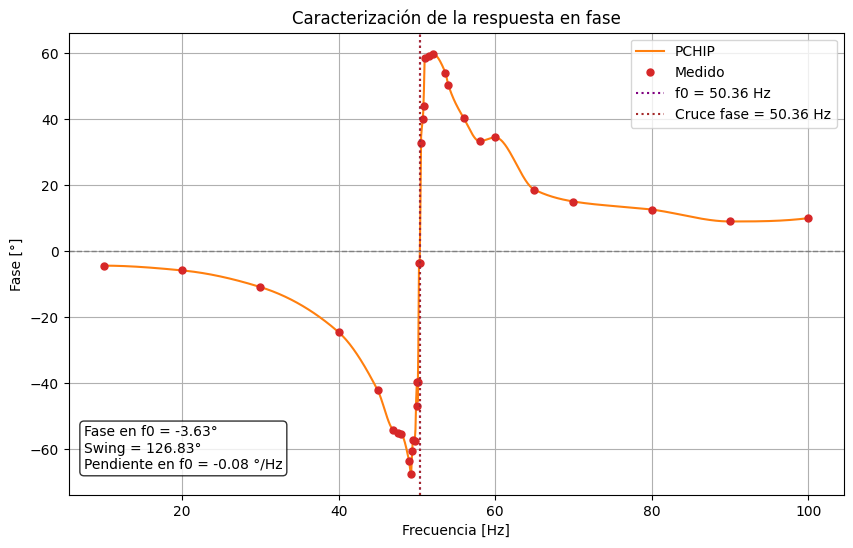

Pico de retardo de grupo: 3.777 mS en 49.189 Hz
Nivel base de retardo (lejos del notch): 0.680 mS
Variación del pico respecto al nivel base: 3.097 mS


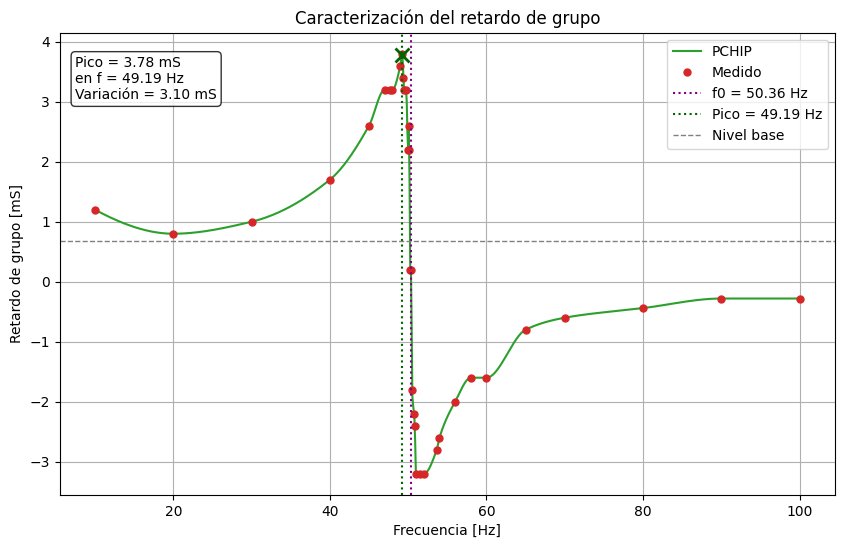

In [7]:
### CARACTERIZACIÓN DEL NOTCH ###

# --- Nivel de referencia de la banda de paso ---
# Tomamos el promedio de magnitud en las zonas alejadas del notch (lejos de f0)
nivel_paso = np.mean(y_mag[(x < 40) | (x > 90)])
print(f"Nivel de banda de paso (referencia): {nivel_paso:.2f} dB")

# --- Frecuencia central (f0): mínimo de la curva interpolada ---
idx_f0 = np.argmin(y_mag_interp)
f0 = x_fino[idx_f0]
mag_min = y_mag_interp[idx_f0]
print(f"Frecuencia central f0: {f0:.3f} Hz")
print(f"Magnitud mínima: {mag_min:.2f} dB")

# --- Profundidad del notch ---
profundidad = nivel_paso - mag_min
print(f"Profundidad del notch: {profundidad:.2f} dB")

# --- Umbral -3 dB relativo a la banda de paso ---
umbral_3db = nivel_paso - 3
print(f"Umbral -3 dB: {umbral_3db:.2f} dB")

# --- Buscar cruces por el umbral -3dB a cada lado de f0 ---
# Lado izquierdo (antes de f0)
lado_izq = y_mag_interp[:idx_f0] - umbral_3db
cruces_izq = np.where(np.diff(np.sign(lado_izq)))[0]
f_izq = x_fino[cruces_izq[-1]] if len(cruces_izq) > 0 else None

# Lado derecho (después de f0)
lado_der = y_mag_interp[idx_f0:] - umbral_3db
cruces_der = np.where(np.diff(np.sign(lado_der)))[0]
f_der = x_fino[idx_f0 + cruces_der[0]] if len(cruces_der) > 0 else None

if f_izq is not None and f_der is not None:
    BW = f_der - f_izq
    Q = f0 / BW
    print(f"Frecuencia de corte inferior (-3dB): {f_izq:.3f} Hz")
    print(f"Frecuencia de corte superior (-3dB): {f_der:.3f} Hz")
    print(f"Ancho de banda (BW): {BW:.3f} Hz")
    print(f"Factor Q: {Q:.2f}")
else:
    print("No se pudieron encontrar ambos cruces de -3dB dentro del rango medido.")
    BW = None
    Q = None

# --- Gráfico con los parámetros marcados ---
plt.figure(figsize=(10, 6))
plt.plot(x_fino, y_mag_interp, '-', label='PCHIP', color='tab:blue')
plt.plot(x, y_mag, 'o', label='Medido', color='tab:red', markersize=5)

plt.axhline(nivel_paso, color='gray', linestyle='--', linewidth=1, label='Nivel banda de paso')
plt.axhline(umbral_3db, color='green', linestyle='--', linewidth=1, label='Umbral -3 dB')
plt.axvline(f0, color='purple', linestyle=':', linewidth=1.5, label=f'f0 = {f0:.2f} Hz')

if f_izq is not None:
    plt.axvline(f_izq, color='orange', linestyle=':', linewidth=1)
if f_der is not None:
    plt.axvline(f_der, color='orange', linestyle=':', linewidth=1)

plt.plot(f0, mag_min, 'x', color='purple', markersize=10, markeredgewidth=2)

texto = f"f0 = {f0:.2f} Hz\nProfundidad = {profundidad:.2f} dB"
if BW is not None:
    texto += f"\nBW = {BW:.2f} Hz\nQ = {Q:.2f}"
plt.text(0.02, 0.05, texto, transform=plt.gca().transAxes,
         fontsize=10, verticalalignment='bottom',
         bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

plt.xlabel('Frecuencia [Hz]')
plt.ylabel('Magnitud [dB]')
plt.title('Caracterización del filtro Notch')
plt.legend(loc='upper right')
plt.grid(True)
plt.show()


### CARACTERIZACIÓN DE LA FASE ###

# --- Cruce por cero de la fase ---
signo_fase = np.sign(y_fase_interp)
cruces_cero = np.where(np.diff(signo_fase))[0]
if len(cruces_cero) > 0:
    idx_cruce = cruces_cero[np.argmin(np.abs(x_fino[cruces_cero] - f0))]
    f_cruce_fase = x_fino[idx_cruce]
    print(f"Frecuencia de cruce por cero de fase: {f_cruce_fase:.3f} Hz")
else:
    f_cruce_fase = None
    print("No se encontró cruce por cero de fase en el rango medido.")

# --- Fase en f0 ---
fase_en_f0 = float(pchip_fase(f0))
print(f"Fase en f0: {fase_en_f0:.2f}°")

# --- Swing de fase (máx - mín) dentro de la zona del notch ---
if f_izq is not None and f_der is not None:
    mask_notch = (x_fino >= f_izq) & (x_fino <= f_der)
else:
    mask_notch = (x_fino >= f0 - 5) & (x_fino <= f0 + 5)

fase_max = y_fase_interp[mask_notch].max()
fase_min = y_fase_interp[mask_notch].min()
swing_fase = fase_max - fase_min
print(f"Swing de fase en la zona del notch: {swing_fase:.2f}° (de {fase_min:.2f}° a {fase_max:.2f}°)")

# --- Pendiente de fase en f0 ---
deriv_fase = pchip_fase.derivative()
pendiente_f0 = float(deriv_fase(f0))
print(f"Pendiente de fase en f0: {pendiente_f0:.2f} °/Hz")

# --- Gráfico de fase caracterizado ---
plt.figure(figsize=(10, 6))
plt.plot(x_fino, y_fase_interp, '-', label='PCHIP', color='tab:orange')
plt.plot(x, y_fase, 'o', label='Medido', color='tab:red', markersize=5)
plt.axvline(f0, color='purple', linestyle=':', linewidth=1.5, label=f'f0 = {f0:.2f} Hz')
if f_cruce_fase is not None:
    plt.axvline(f_cruce_fase, color='brown', linestyle=':', linewidth=1.5, label=f'Cruce fase = {f_cruce_fase:.2f} Hz')
    plt.axhline(0, color='gray', linestyle='--', linewidth=1)

texto_fase = f"Fase en f0 = {fase_en_f0:.2f}°\nSwing = {swing_fase:.2f}°\nPendiente en f0 = {pendiente_f0:.2f} °/Hz"
plt.text(0.02, 0.05, texto_fase, transform=plt.gca().transAxes,
         fontsize=10, verticalalignment='bottom',
         bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

plt.xlabel('Frecuencia [Hz]')
plt.ylabel('Fase [°]')
plt.title('Caracterización de la respuesta en fase')
plt.legend(loc='upper right')
plt.grid(True)
plt.show()


### CARACTERIZACIÓN DEL RETARDO DE GRUPO ###

# --- Pico de retardo de grupo (valor absoluto) ---
idx_pico_delay = np.argmax(np.abs(y_delay_interp))
f_pico_delay = x_fino[idx_pico_delay]
delay_pico = y_delay_interp[idx_pico_delay]
print(f"Pico de retardo de grupo: {delay_pico:.3f} mS en {f_pico_delay:.3f} Hz")

# --- Nivel base del retardo (lejos del notch) ---
nivel_base_delay = np.mean(y_delay[(x < 40) | (x > 90)])
print(f"Nivel base de retardo (lejos del notch): {nivel_base_delay:.3f} mS")

# --- Variación del pico respecto al nivel base ---
variacion_delay = delay_pico - nivel_base_delay
print(f"Variación del pico respecto al nivel base: {variacion_delay:.3f} mS")

# --- Gráfico de retardo caracterizado ---
plt.figure(figsize=(10, 6))
plt.plot(x_fino, y_delay_interp, '-', label='PCHIP', color='tab:green')
plt.plot(x, y_delay, 'o', label='Medido', color='tab:red', markersize=5)
plt.axvline(f0, color='purple', linestyle=':', linewidth=1.5, label=f'f0 = {f0:.2f} Hz')
plt.axvline(f_pico_delay, color='darkgreen', linestyle=':', linewidth=1.5, label=f'Pico = {f_pico_delay:.2f} Hz')
plt.axhline(nivel_base_delay, color='gray', linestyle='--', linewidth=1, label='Nivel base')
plt.plot(f_pico_delay, delay_pico, 'x', color='darkgreen', markersize=10, markeredgewidth=2)

texto_delay = f"Pico = {delay_pico:.2f} mS\nen f = {f_pico_delay:.2f} Hz\nVariación = {variacion_delay:.2f} mS"
plt.text(0.02, 0.95, texto_delay, transform=plt.gca().transAxes,
         fontsize=10, verticalalignment='top',
         bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

plt.xlabel('Frecuencia [Hz]')
plt.ylabel('Retardo de grupo [mS]')
plt.title('Caracterización del retardo de grupo')
plt.legend(loc='upper right')
plt.grid(True)
plt.show()

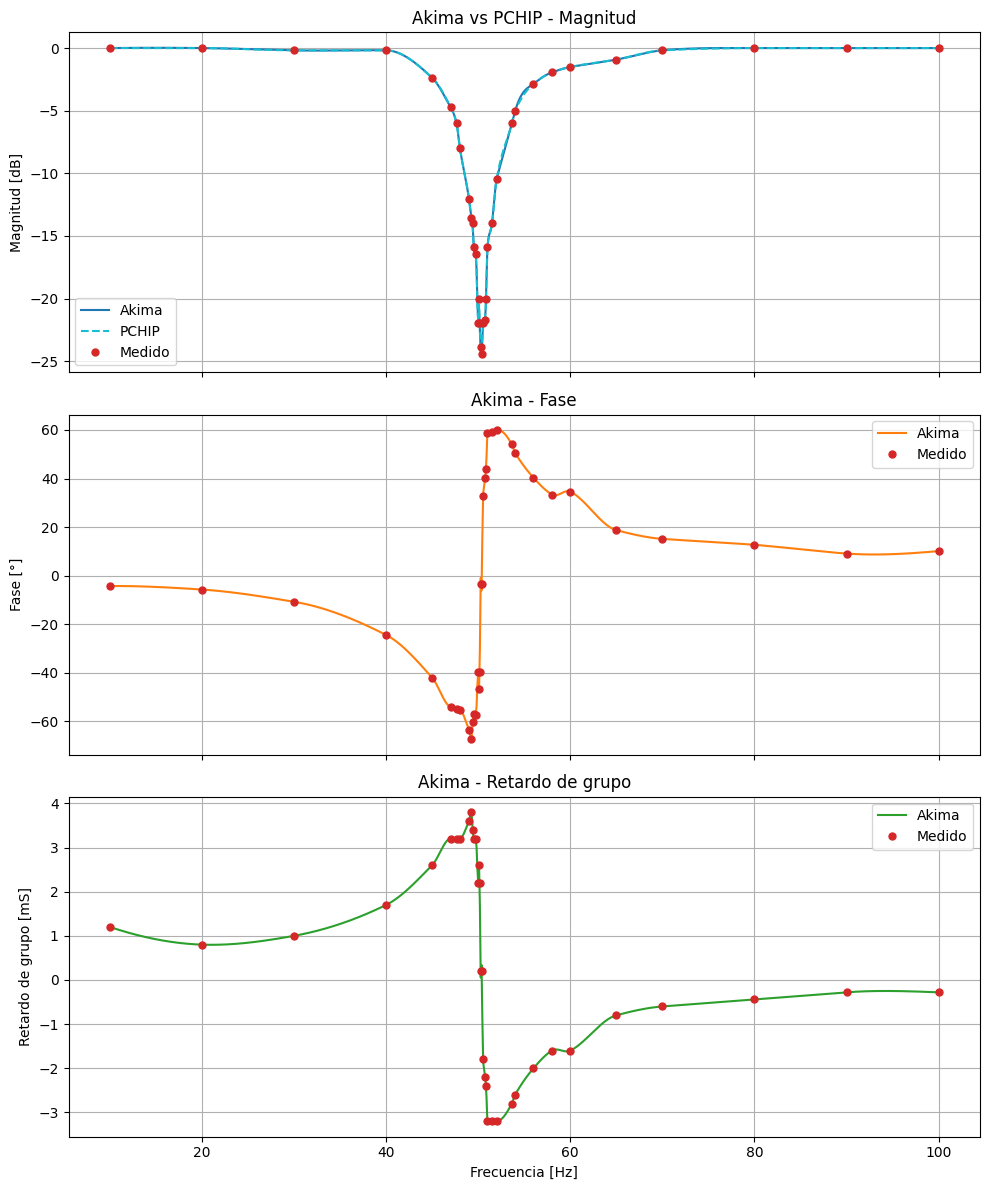

In [8]:
### INTERPOLACIÓN AKIMA ###
from scipy.interpolate import Akima1DInterpolator

df_akima = df.drop_duplicates(subset='Frecuencia [Hz]').sort_values('Frecuencia [Hz]').reset_index(drop=True)

x = df_akima['Frecuencia [Hz]'].values
y_mag   = df_akima['Vout [dB]'].values
y_fase  = np.degrees(df_akima['Fase [rad]'].values)
y_delay = df_akima['Delta T [mS]'].values

akima_mag   = Akima1DInterpolator(x, y_mag)
akima_fase  = Akima1DInterpolator(x, y_fase)
akima_delay = Akima1DInterpolator(x, y_delay)

x_fino = np.linspace(x.min(), x.max(), 1000)

y_mag_akima   = akima_mag(x_fino)
y_fase_akima  = akima_fase(x_fino)
y_delay_akima = akima_delay(x_fino)

# --- Comparación Akima vs PCHIP en magnitud ---
from scipy.interpolate import PchipInterpolator
pchip_mag = PchipInterpolator(x, y_mag)
y_mag_pchip = pchip_mag(x_fino)

fig, axs = plt.subplots(3, 1, figsize=(10, 12), sharex=True)

axs[0].plot(x_fino, y_mag_akima, '-', label='Akima', color='tab:blue')
axs[0].plot(x_fino, y_mag_pchip, '--', label='PCHIP', color='tab:cyan')
axs[0].plot(x, y_mag, 'o', label='Medido', color='tab:red', markersize=5)
axs[0].set_ylabel('Magnitud [dB]')
axs[0].set_title('Akima vs PCHIP - Magnitud')
axs[0].legend()
axs[0].grid(True)

axs[1].plot(x_fino, y_fase_akima, '-', color='tab:orange', label='Akima')
axs[1].plot(x, y_fase, 'o', color='tab:red', markersize=5, label='Medido')
axs[1].set_ylabel('Fase [°]')
axs[1].set_title('Akima - Fase')
axs[1].legend()
axs[1].grid(True)

axs[2].plot(x_fino, y_delay_akima, '-', color='tab:green', label='Akima')
axs[2].plot(x, y_delay, 'o', color='tab:red', markersize=5, label='Medido')
axs[2].set_xlabel('Frecuencia [Hz]')
axs[2].set_ylabel('Retardo de grupo [mS]')
axs[2].set_title('Akima - Retardo de grupo')
axs[2].legend()
axs[2].grid(True)

plt.tight_layout()
plt.show()

f0 ajustado: 50.3316 Hz
Q ajustado: 8.6300
K ajustado: 0.8571
BW estimado (f0/Q): 5.8322 Hz


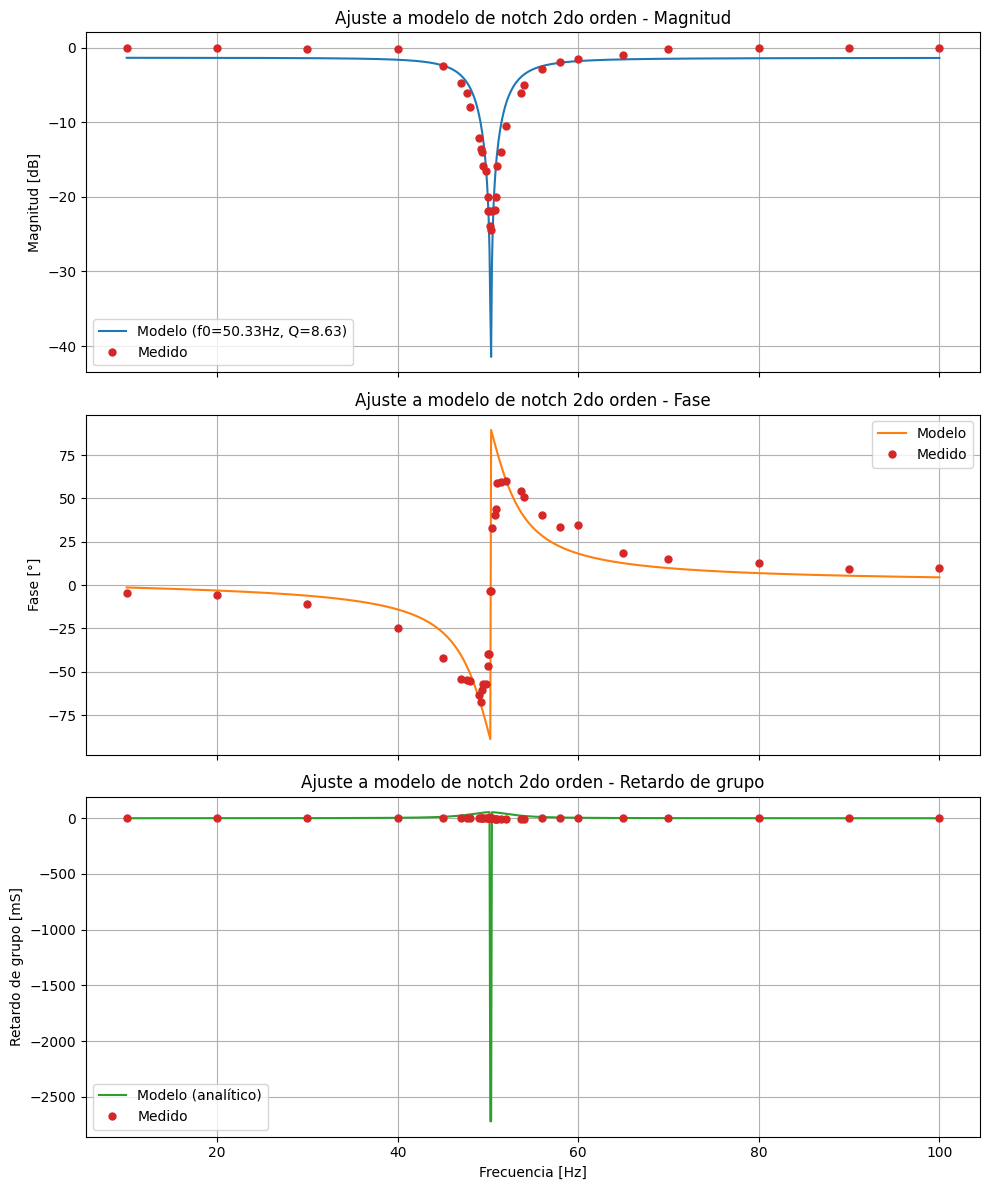

In [9]:
### AJUSTE A MODELO FÍSICO - NOTCH DE 2DO ORDEN ###
from scipy.optimize import least_squares

df_modelo = df.drop_duplicates(subset='Frecuencia [Hz]').sort_values('Frecuencia [Hz]').reset_index(drop=True)

f_medido    = df_modelo['Frecuencia [Hz]'].values
mag_db_medido = df_modelo['Vout [dB]'].values
fase_medido   = df_modelo['Fase [rad]'].values  # en radianes

def notch_H(f, f0, Q, K):
    """Función de transferencia de un notch de 2do orden ideal."""
    w  = 2 * np.pi * f
    w0 = 2 * np.pi * f0
    s  = 1j * w
    H  = K * (s**2 + w0**2) / (s**2 + (w0 / Q) * s + w0**2)
    return H

def residuales(params, f, mag_db_meas, fase_meas):
    f0, Q, K = params
    H = notch_H(f, f0, Q, K)
    mag_db_modelo = 20 * np.log10(np.abs(H) + 1e-12)
    fase_modelo   = np.angle(H)
    # Ponderamos igual magnitud y fase pero en unidades comparables
    res_mag  = mag_db_modelo - mag_db_meas
    res_fase = np.degrees(fase_modelo - fase_meas)  # pasamos a grados para escala similar a dB
    return np.concatenate([res_mag, res_fase])

# --- Valores iniciales (ajustar si el fit no converge bien) ---
p0 = [50.3, 5.0, 1.0]  # f0, Q, K

resultado = least_squares(residuales, p0, args=(f_medido, mag_db_medido, fase_medido))
f0_fit, Q_fit, K_fit = resultado.x

print(f"f0 ajustado: {f0_fit:.4f} Hz")
print(f"Q ajustado: {Q_fit:.4f}")
print(f"K ajustado: {K_fit:.4f}")
print(f"BW estimado (f0/Q): {f0_fit/Q_fit:.4f} Hz")

# --- Evaluar el modelo ajustado en una grilla fina ---
f_fino = np.linspace(f_medido.min(), f_medido.max(), 1000)
H_fit = notch_H(f_fino, f0_fit, Q_fit, K_fit)
mag_fit_db = 20 * np.log10(np.abs(H_fit))
fase_fit_deg = np.degrees(np.angle(H_fit))

# --- Retardo de grupo analítico: -dφ/dω ---
w_fino = 2 * np.pi * f_fino
fase_fit_rad = np.unwrap(np.angle(H_fit))
delay_fit_s = -np.gradient(fase_fit_rad, w_fino)
delay_fit_ms = delay_fit_s * 1000

# --- Gráficos ---
fig, axs = plt.subplots(3, 1, figsize=(10, 12), sharex=True)

axs[0].plot(f_fino, mag_fit_db, '-', color='tab:blue', label=f'Modelo (f0={f0_fit:.2f}Hz, Q={Q_fit:.2f})')
axs[0].plot(f_medido, mag_db_medido, 'o', color='tab:red', markersize=5, label='Medido')
axs[0].set_ylabel('Magnitud [dB]')
axs[0].set_title('Ajuste a modelo de notch 2do orden - Magnitud')
axs[0].legend()
axs[0].grid(True)

axs[1].plot(f_fino, fase_fit_deg, '-', color='tab:orange', label='Modelo')
axs[1].plot(f_medido, np.degrees(fase_medido), 'o', color='tab:red', markersize=5, label='Medido')
axs[1].set_ylabel('Fase [°]')
axs[1].set_title('Ajuste a modelo de notch 2do orden - Fase')
axs[1].legend()
axs[1].grid(True)

axs[2].plot(f_fino, delay_fit_ms, '-', color='tab:green', label='Modelo (analítico)')
axs[2].plot(f_medido, df_modelo['Delta T [mS]'].values, 'o', color='tab:red', markersize=5, label='Medido')
axs[2].set_xlabel('Frecuencia [Hz]')
axs[2].set_ylabel('Retardo de grupo [mS]')
axs[2].set_title('Ajuste a modelo de notch 2do orden - Retardo de grupo')
axs[2].legend()
axs[2].grid(True)

plt.tight_layout()
plt.show()

/tmp/ipykernel_779/3828527910.py:18: RuntimeWarning: divide by zero encountered in log10
  mag_ideal_db = 20 * np.log10(np.abs(H_ideal_fino))


RMSE magnitud (medido vs ideal): 37.67 dB
RMSE fase (medido vs ideal): 42.69°


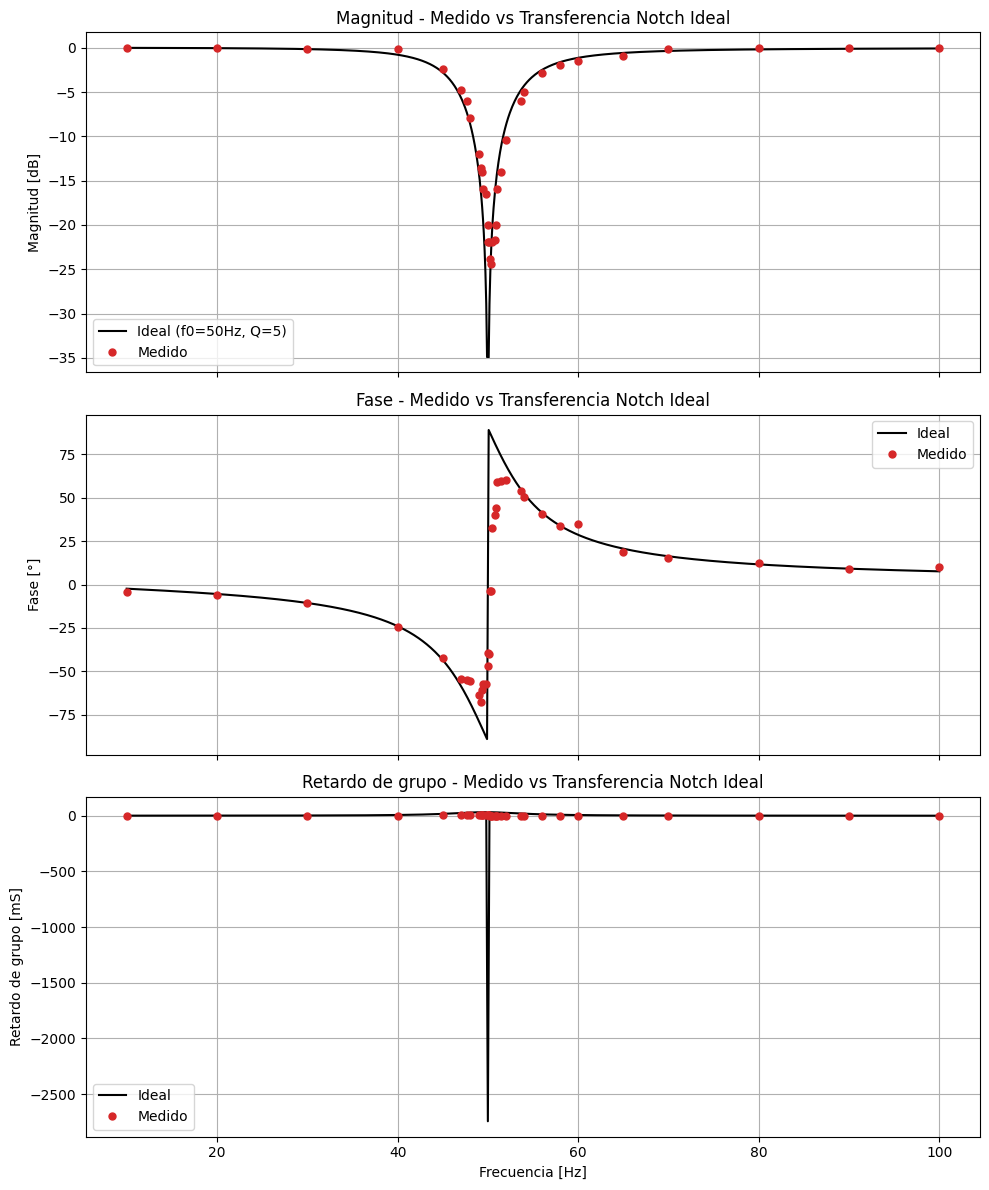

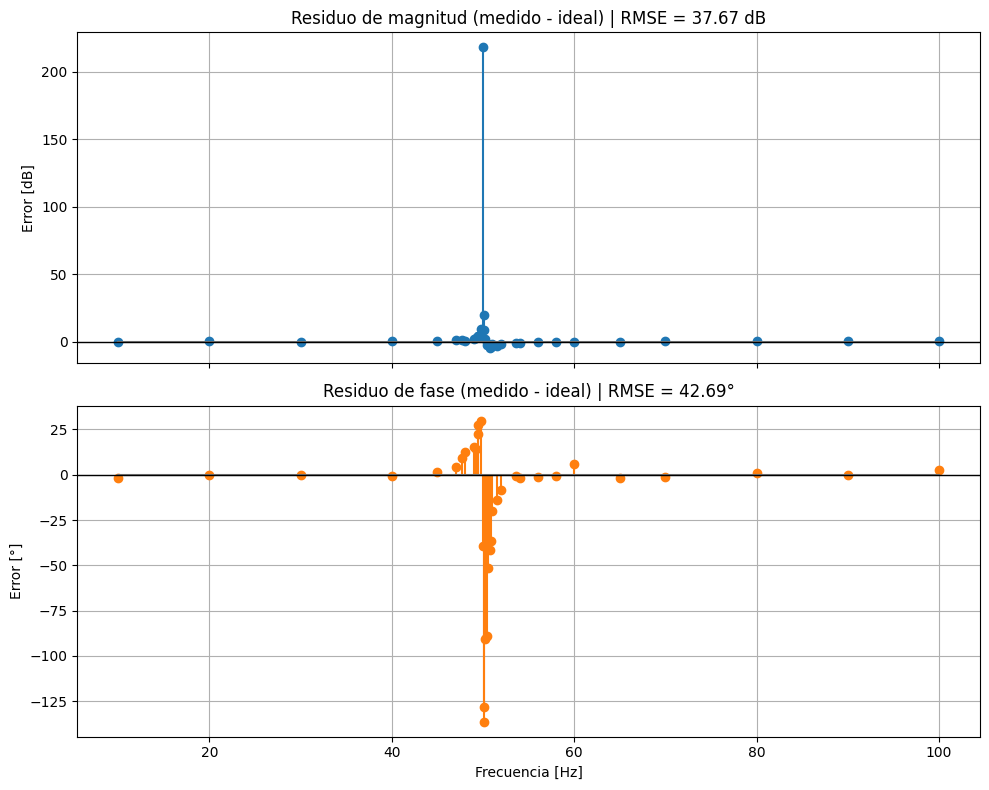

In [13]:
### COMPARACIÓN CONTRA TRANSFERENCIA NOTCH IDEAL ###

# --- Parámetros del diseño teórico (del filtro tipo B) ---
f0_ideal = 50.0        # Hz
Q_ideal  = 5.0          # Q = f0 / BW = 50/10
w0_ideal = 2 * np.pi * f0_ideal  # = 100*pi rad/s

def notch_ideal(f, f0, Q):
    """T(s) = (s^2 + w0^2) / (s^2 + s*w0/Q + w0^2), evaluada en s = j*2*pi*f"""
    w0 = 2 * np.pi * f0
    s = 1j * 2 * np.pi * f
    return (s**2 + w0**2) / (s**2 + s * (w0 / Q) + w0**2)

# --- Evaluar el modelo ideal en grilla fina y en los puntos medidos ---
f_fino = np.linspace(df['Frecuencia [Hz]'].min(), df['Frecuencia [Hz]'].max(), 1000)

H_ideal_fino = notch_ideal(f_fino, f0_ideal, Q_ideal)
mag_ideal_db = 20 * np.log10(np.abs(H_ideal_fino))
fase_ideal_deg = np.degrees(np.angle(H_ideal_fino))

# Retardo de grupo ideal: -dφ/dω (numérico sobre la curva ideal)
w_fino = 2 * np.pi * f_fino
fase_ideal_rad_unwrap = np.unwrap(np.angle(H_ideal_fino))
delay_ideal_s = -np.gradient(fase_ideal_rad_unwrap, w_fino)
delay_ideal_ms = delay_ideal_s * 1000

# --- Evaluar el modelo ideal justo en las frecuencias medidas (para calcular error) ---
df_comp = df.drop_duplicates(subset='Frecuencia [Hz]').sort_values('Frecuencia [Hz]').reset_index(drop=True)
f_medido = df_comp['Frecuencia [Hz]'].values

H_ideal_en_medido = notch_ideal(f_medido, f0_ideal, Q_ideal)
mag_ideal_en_medido = 20 * np.log10(np.abs(H_ideal_en_medido) + 1e-12)
fase_ideal_en_medido = np.degrees(np.angle(H_ideal_en_medido))

error_mag = df_comp['Vout [dB]'].values - mag_ideal_en_medido
error_fase = np.degrees(df_comp['Fase [rad]'].values) - fase_ideal_en_medido

rmse_mag = np.sqrt(np.mean(error_mag**2))
rmse_fase = np.sqrt(np.mean(error_fase**2))

print(f"RMSE magnitud (medido vs ideal): {rmse_mag:.2f} dB")
print(f"RMSE fase (medido vs ideal): {rmse_fase:.2f}°")

# --- Gráficos: medido vs ideal ---
fig, axs = plt.subplots(3, 1, figsize=(10, 12), sharex=True)

axs[0].plot(f_fino, mag_ideal_db, '-', color='black', linewidth=1.5, label=f'Ideal (f0=50Hz, Q=5)')
axs[0].plot(df['Frecuencia [Hz]'], df['Vout [dB]'], 'o', color='tab:red', markersize=5, label='Medido')
axs[0].set_ylabel('Magnitud [dB]')
axs[0].set_title('Magnitud - Medido vs Transferencia Notch Ideal')
axs[0].legend()
axs[0].grid(True)

axs[1].plot(f_fino, fase_ideal_deg, '-', color='black', linewidth=1.5, label='Ideal')
axs[1].plot(df['Frecuencia [Hz]'], np.degrees(df['Fase [rad]']), 'o', color='tab:red', markersize=5, label='Medido')
axs[1].set_ylabel('Fase [°]')
axs[1].set_title('Fase - Medido vs Transferencia Notch Ideal')
axs[1].legend()
axs[1].grid(True)

axs[2].plot(f_fino, delay_ideal_ms, '-', color='black', linewidth=1.5, label='Ideal')
axs[2].plot(df['Frecuencia [Hz]'], df['Delta T [mS]'], 'o', color='tab:red', markersize=5, label='Medido')
axs[2].set_xlabel('Frecuencia [Hz]')
axs[2].set_ylabel('Retardo de grupo [mS]')
axs[2].set_title('Retardo de grupo - Medido vs Transferencia Notch Ideal')
axs[2].legend()
axs[2].grid(True)

plt.tight_layout()
plt.show()

# --- Gráfico adicional: error (residuo) en magnitud y fase, punto por punto ---
fig, axs = plt.subplots(2, 1, figsize=(10, 8), sharex=True)

axs[0].stem(f_medido, error_mag, linefmt='tab:blue', markerfmt='o', basefmt='gray')
axs[0].axhline(0, color='black', linewidth=1)
axs[0].set_ylabel('Error [dB]')
axs[0].set_title(f'Residuo de magnitud (medido - ideal) | RMSE = {rmse_mag:.2f} dB')
axs[0].grid(True)

axs[1].stem(f_medido, error_fase, linefmt='tab:orange', markerfmt='o', basefmt='gray')
axs[1].axhline(0, color='black', linewidth=1)
axs[1].set_xlabel('Frecuencia [Hz]')
axs[1].set_ylabel('Error [°]')
axs[1].set_title(f'Residuo de fase (medido - ideal) | RMSE = {rmse_fase:.2f}°')
axs[1].grid(True)

plt.tight_layout()
plt.show()

### Analizador de espectros
Por ultimo, utilizamos un $\textbf{Analizado de Espectros}$ como ultima instancia de la practica para realizar un barrido en frecuencia en tiempo real, lo que nos perimitio visualizar en tiempo real como realizar un barrido en frecuencia automatico con alta precision deterministica, validando nuestro filtro de una forma mas robusta ya que tuvimos que hacerle ajustes finos al circuito con los potenciometros utilizados para que levante correctamente la señal deseada. 
![Analizador de espectros Modulo](Modulo_analizador_espectral.jpeg)
![Analizador de espectros Fase](fase_analizador_espectral.jpeg)


### Conclusiones
En este trabajo hemos logrado con creses el objetivo propueso del filtro analogico tipo notch en 50Hz logrando una atenuacion aproximada de -22db.  donde pusimos en practica todo lo visto en la materia hasta ahora en el diseño, pero ahora llevandolo a un entorno de trabajo real al pasarlo a una plaqueta fisica. En el medio tuvimos que sortear una serie de inconvenientes como lo son ajustes de diseño para una facil implementacion con los materiales disponibles, subdivision y aislacion de subcircuitos dentro del circuito completo para su analisis y verificacion de correcto funcionamiento. 
Como mejoras el uso de componentes mas precisos y el analisis de otros operacionales de mejores caracteristicas podrian hacer un filtrado mas ajustado todavia u agregando variables de ajuste a la ecuacion ya que por como armamos el circuito solo podiamos hacer un ajuste en la frecuencia de corte de este y no en el factor de selectividad por ejemplo. 